In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [145]:
def band_pass(p1,p2,freqs,power_FFT):
    ids= [np.where(freqs >= p1)[0][0], np.where(freqs <= p2)[0][-1]]
    freqs_s = freqs[ids[0]:]
    power_FFT_s = power_FFT[ids[0]:, :]
    return freqs_s,power_FFT_s

In [158]:
def read_plot(path, time=500):
    data = pd.read_csv(path)
    print(data.head())
    print(data.info())
    data = np.array(data)
    data = data[:, 0:14]
    data=data-np.mean(data,axis=0)
    for i in range(14):
        plt.plot(data[:500, i] + (100 * i), label=str(i))
    plt.legend(loc='upper right')
    plt.show()

    power_FFT =  (np.abs(np.fft.rfft(data,axis=0)) ** 2) / (data.shape[0] * 128)
    print(np.array(power_FFT).shape)
    freqs = np.fft.rfftfreq(data.shape[0], 1/128)
    print(freqs.shape)
    freqs,power_FFT=band_pass(0.65,5,freqs,power_FFT)
    power_FFT=np.mean(power_FFT,axis=1)
    
    plt.bar(freqs,power_FFT)
    plt.show()

       AF3      AF4       F3       F4       F7        F8      FC5     FC6  \
0 -33.0205 -15.1846 -42.1795   1.6872  42.1793  -1.68720  -5.5436 -3.6154   
1 -28.6291 -20.0583 -42.5410 -10.4653  35.3100 -15.68600 -19.3110 -2.4344   
2 -21.8497 -10.9006 -32.0346  -2.3656  39.6993  -0.64483  -4.0523 -1.0830   
3 -25.1185 -10.9702 -32.7641  -3.4287  32.7378   4.69650  -8.6299 -1.7412   
4 -19.0316  -9.5886 -29.1108  -3.9459  35.3533   0.79929 -12.6914  1.0144   

        O1       O2       P7       P8       T7       T8  Unnamed: 14  
0  25.7899 -9.88190   5.5436  7.47180  11.8101  17.1128          NaN  
1  17.4933  3.24420  18.7081  5.09510  17.3683   3.0708          NaN  
2  26.8081 -3.45840   8.1861  8.40480  15.1209   9.3940          NaN  
3  16.7637 -9.75860   1.1868  0.91086   4.3315   8.1073          NaN  
4  13.1068 -0.73692   8.1054 -1.31300   8.1694   8.3442          NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38252 entries, 0 to 38251
Data columns (total 15 columns):
 #

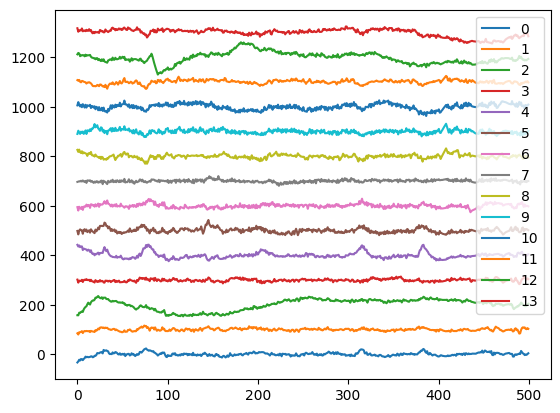

(19127, 14)
(19127,)


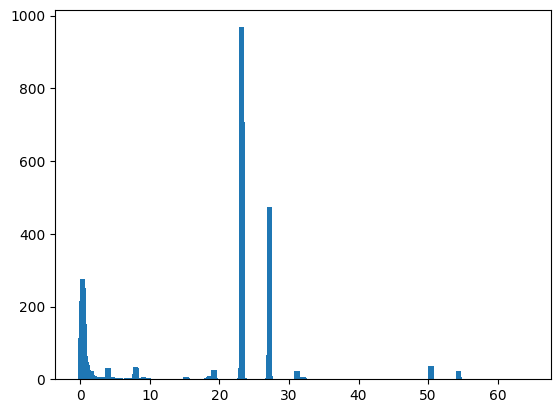

In [134]:
read_plot('C:\\Users\\Kagero\\PycharmProjects\\Games Emotion Clasification\\GAMEEMO\\(S01)\\Preprocessed EEG Data\\.csv format\\S01G1AllChannels.csv')

       AF3      AF4       F3       F4       F7       F8      FC5     FC6  \
0 -35.1282 -16.1538 -44.8718   1.7949  44.8716  -1.7949  -5.8975 -3.8462   
1 -32.5642 -22.3079 -47.9487 -11.0256  40.2561 -16.7949 -20.8975 -2.8206   
2 -27.1794 -13.8459 -39.4871  -3.0769  47.1794  -1.7949  -5.8975 -1.5383   
3 -32.0515 -14.6157 -42.3079  -4.3589  42.3076   3.8462 -11.0259 -2.3076   
4 -27.1794 -13.8462 -40.5127  -5.1279  47.1797   0.0000 -15.8975  0.5127   

        O1       O2       P7      P8       T7       T8  Unnamed: 14  
0  27.4360 -10.5127   5.8975  7.9487  12.5640  18.2051          NaN  
1  20.2561   2.8206  20.2561  5.8972  19.2307   4.3591          NaN  
2  31.2820  -4.1028  10.2566  9.7434  17.9485  11.2820          NaN  
3  22.3076 -11.0259   3.3330  2.3076   7.4355  10.5127          NaN  
4  19.4873  -2.0513  10.7690  0.0000  11.7949  11.2822          NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38252 entries, 0 to 38251
Data columns (total 15 columns):
 #   Column   

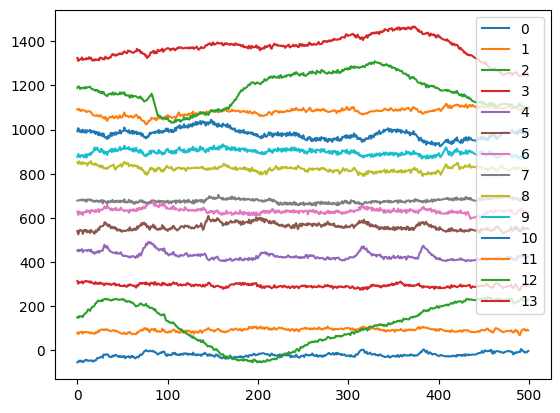

(19127, 14)
(19127,)


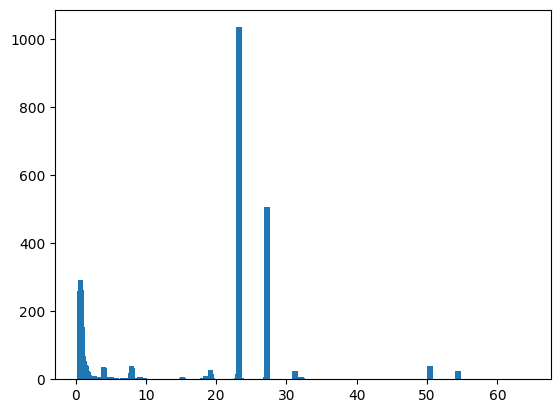

In [159]:
read_plot('C:\\Users\\Kagero\\PycharmProjects\\Games Emotion Clasification\\GAMEEMO\\(S01)\\Raw EEG Data\\.csv format\\S01G1AllRawChannels.csv')

       AF3      AF4       F3       F4         F7       F8      FC5      FC6  \
0  49.4872   9.9999  51.5385 -41.2821 -30.000100 -58.7179 -73.5897  -8.9745   
1  46.4104  24.9999  66.5385 -26.2821 -15.000100 -43.7179 -58.5897 -13.5898   
2  31.4104  39.9999  66.6665 -11.2821  -0.000122 -28.7179 -46.1538 -28.5898   
3  16.4104  40.0000  73.3335   0.0000  -3.589800 -13.7179 -49.2307 -43.5898   
4  25.6409  26.6667  73.8464   1.5383  -3.589600  -7.6921 -34.2307 -58.4614   

        O1        O2        P7       P8       T7       T8  Unnamed: 14  
0  -3.3334  44.35880  140.2562  54.6151   3.3334 -31.5385          NaN  
1  11.6666  29.35880  128.4617  50.5129  -3.3333 -16.5385          NaN  
2  26.6666  14.35880  113.4617  35.5129 -18.3333 -11.7949          NaN  
3  41.6666  -0.64124   98.4617  31.2822 -33.3333   0.0000          NaN  
4  56.6666 -15.64120   91.2820  40.5129 -30.7693  -1.5383          NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38252 entries, 0 to 38251
Data column

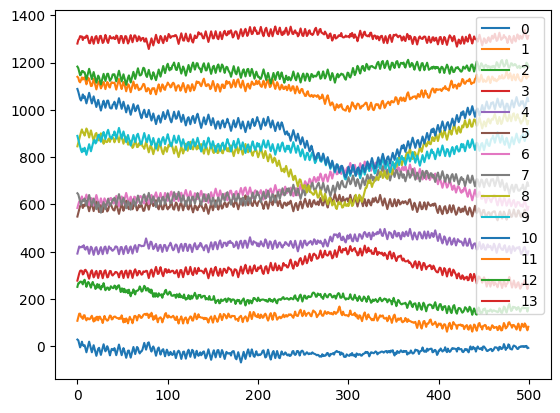

(19127, 14)
(19127,)


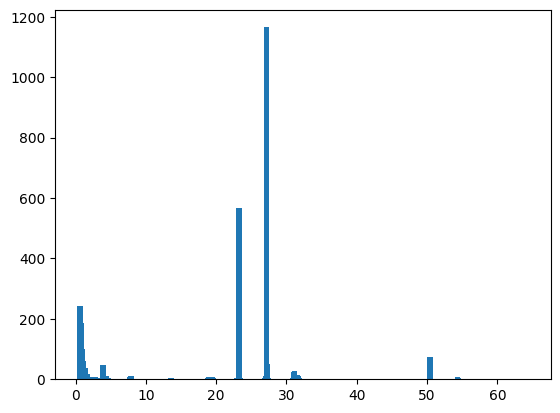

In [162]:
read_plot('C:\\Users\\Kagero\\PycharmProjects\\Games Emotion Clasification\\GAMEEMO\\(S01)\\Raw EEG Data\\.csv format\\S01G2AllRawChannels.csv')

       AF3      AF4        F3       F4       F7       F8     FC5      FC6  \
0  55.8972 -35.8975   96.9231 -20.5129 -61.5386  51.2820  2.0515 -11.7947   
1  55.3845 -33.3333   93.3333 -14.8718 -69.7437  42.5642  3.0769 -11.7947   
2  52.3081 -30.2561   95.3848  -7.1792 -66.6665  36.4106  0.0000 -11.2820   
3  55.3848 -28.7180  101.0259  -2.5640 -53.3333  45.1284  2.0513 -11.2822   
4  61.5386 -32.3079  101.5386  -8.2053 -53.3335  39.4873 -2.0513  -7.6924   

        O1      O2       P7       P8       T7      T8  Unnamed: 14  
0  45.1282 -2.0515  78.9744  -6.6667  23.5896 -5.1282          NaN  
1  34.8718 -6.6667  74.3591  -9.7434  10.2566 -3.0769          NaN  
2  41.5386  0.0000  75.8975 -13.3333   8.2051 -6.1538          NaN  
3  52.3076 -2.0513  74.3589 -17.4360  14.8716 -5.6411          NaN  
4  43.0767  2.0513  81.0254 -12.8206  11.2817 -4.6152          NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38252 entries, 0 to 38251
Data columns (total 15 columns):
 #   Column   

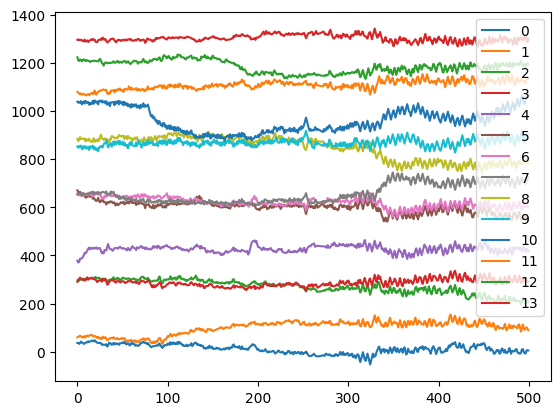

(19127, 14)
(19127,)


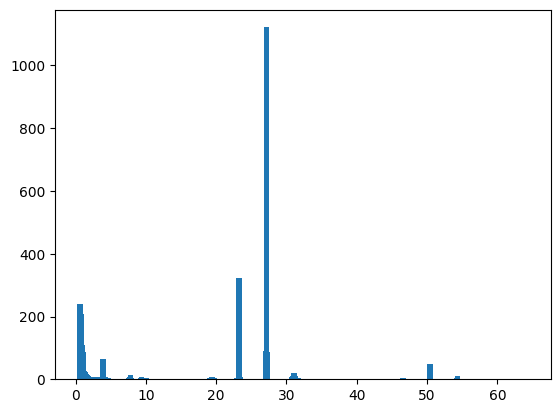

In [160]:
read_plot('C:\\Users\\Kagero\\PycharmProjects\\Games Emotion Clasification\\GAMEEMO\\(S01)\\Raw EEG Data\\.csv format\\S01G3AllRawChannels.csv')

        AF3      AF4       F3        F4       F7       F8      FC5      FC6  \
0  -3.84620  0.76904  1.28220   5.38480  -5.3848  -5.3848 -17.6924 -1.28220   
1 -10.51290 -4.35910 -2.30790  -0.25659 -13.0769  -9.9998 -27.4358  0.25659   
2  -5.89750 -2.82060  0.25659  -0.25659 -12.5642 -13.0769 -32.5642  2.82060   
3   0.51294  3.07690  3.58960  12.30790  -6.6667  -2.5642 -21.0256 -2.05100   
4  -7.94870 -1.79470  2.30790   7.94900 -16.6665 -11.0256 -26.9231  1.28200   

         O1       O2       P7       P8       T7       T8  Unnamed: 14  
0  27.94870   7.9487  13.5898  13.0771 -0.76904 -4.35890          NaN  
1  12.94870   9.4871   8.9744  10.5129  1.28200  0.76929          NaN  
2  -2.05130  11.0256  14.6155   9.4871  2.82060  0.25659          NaN  
3  -0.51294  -1.0256   4.6155   6.1541 -3.58960  1.53830          NaN  
4  -1.28200  13.9744  10.0002  15.6409 -7.94870  3.33330          NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38252 entries, 0 to 38251
Data columns (tot

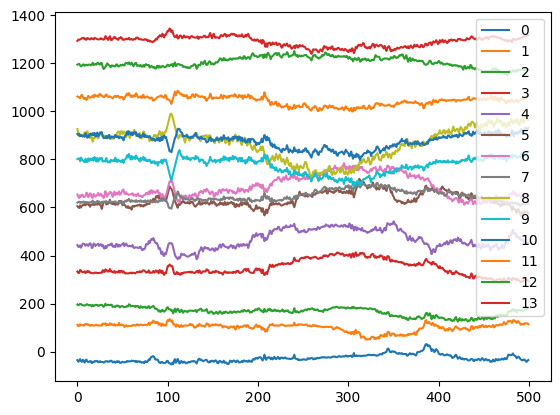

(19127, 14)
(19127,)


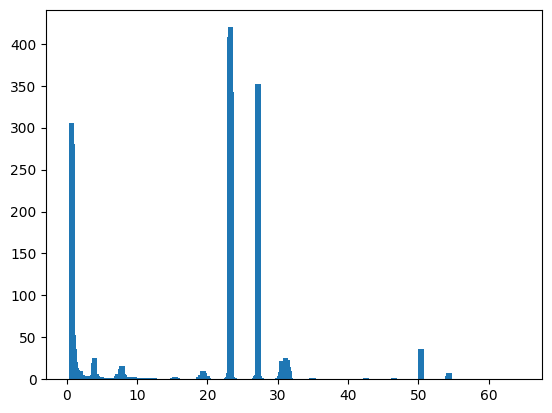

In [161]:
read_plot('C:\\Users\\Kagero\\PycharmProjects\\Games Emotion Clasification\\GAMEEMO\\(S01)\\Raw EEG Data\\.csv format\\S01G4AllRawChannels.csv')